## Phase 6c - SciBERT Transformer

This notebook implements transformer-based models for drug–drug interaction (DDI) classification using the SemEval-2013 dataset. Pretrained biomedical language models including BioBERT, PubMedBERT, and SciBERT are fine-tuned to capture domain-specific semantic relationships between drug entities.

The pipeline follows a structured approach including dataset preparation, tokenisation with special drug markers, class imbalance handling using weighted loss, and model training with early stopping based on Macro F1. Evaluation is performed using multiple metrics such as Macro F1, balanced accuracy, and Matthews Correlation Coefficient to ensure robust performance assessment on imbalanced multi-class data.

## Environment and Model Setup

This section initialises the SciBERT training environment, including required libraries, configuration parameters, and reproducibility settings.

The computation device is automatically selected (CUDA, MPS, or CPU), and training hyperparameters are loaded from the central configuration. Output directories and visualisation settings are also defined to ensure consistency across experiments.

This unified setup enables controlled and reproducible transformer-based training using SciBERT.

In [1]:
# Path Setup
import sys, os
sys.path.insert(0, os.path.abspath('../'))

from config import *


# Standard Library Imports
import json
import pickle
import warnings
import random
from pathlib import Path


# Data Handling
import numpy as np
import pandas as pd


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


# Deep Learning
import torch
import torch.nn as nn
from torch.utils.data import Dataset


# Transformers
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    EvalPrediction,
)


# ML Utilities
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score,
)


# Configuration Setup
warnings.filterwarnings('ignore')


# Reproducibility
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)


# Device Selection
DEVICE = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps' if torch.backends.mps.is_available() else
    'cpu'
)

print(f'Device : {DEVICE}')

if DEVICE.type == 'cuda':
    print(f'GPU : {torch.cuda.get_device_name(0)}')
    print(f'VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
elif DEVICE.type == 'cpu':
    print('WARNING: CPU-only. ~2 hrs expected. Google Colab T4 is recommended.')


# Model Configuration
MODEL_NAME = 'SciBERT'
MODEL_ID = SCIBERT_MODEL_ID
CASED = False


# Output Directories
OUTPUT_DIR = SCIBERT_DIR
FIG_DIR = Path(str(PLOTS_SCIBERT_DIR))
FIG_DIR.mkdir(parents=True, exist_ok=True)


# Training Parameters
MAX_LEN = TRANSFORMER_MAX_LEN
BATCH_SIZE = TRANSFORMER_BATCH_SIZE
EPOCHS = TRANSFORMER_EPOCHS
LR = TRANSFORMER_LR
WARMUP_RATIO = TRANSFORMER_WARMUP
WEIGHT_DECAY = TRANSFORMER_WD

TEXT_COL = 'sentence_masked' if USE_DRUG_MASKING else 'sentence_original'


# Plot Styling
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})


# Label Colours
LABEL_COLOURS = {
    'false': '#888780',
    'effect': '#378ADD',
    'mechanism': '#7F77DD',
    'advise': '#EF9F27',
    'int': '#D85A30',
}

for path in [TRAIN_PROCESSED, TEST_PROCESSED]:
    status = 'FOUND' if os.path.exists(path) else 'NOT FOUND'

Device : cuda
GPU : NVIDIA GeForce RTX 5060 Laptop GPU
VRAM : 8.5 GB


## Data Loading and Train Validation Split

This section loads the processed datasets and prepares them for training. Labels are mapped to numerical values for model compatibility.

A group-based split using sentence identifiers ensures that no sentence appears in both training and validation sets, preventing data leakage and ensuring reliable evaluation.

In [2]:
# Load Data
print('Loading data')

train_df = pd.read_csv(TRAIN_PROCESSED)
test_df = pd.read_csv(TEST_PROCESSED)

print(f'Train: {len(train_df):,} rows | Test: {len(test_df):,} rows')


# Column Checks
for col in [TEXT_COL, 'interaction_type', 'sentence_id']:
    assert col in train_df.columns, f'Missing column: {col} — run Phase 3 first'


# Label Mapping
train_df['label'] = train_df['interaction_type'].map(LABEL2ID)
test_df['label']  = test_df['interaction_type'].map(LABEL2ID)

assert train_df['label'].isna().sum() == 0, 'Unmapped labels'


# Train–Validation Split
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.1,
    random_state=RANDOM_STATE
)

tr_idx, val_idx = next(
    gss.split(train_df, train_df['label'], groups=train_df['sentence_id'])
)

train_split = train_df.iloc[tr_idx].reset_index(drop=True)
val_split = train_df.iloc[val_idx].reset_index(drop=True)


# Leakage Check
overlap = set(train_split['sentence_id']) & set(val_split['sentence_id'])
assert len(overlap) == 0, f'Sentence leakage: {len(overlap)} shared IDs'


# Summary
print(f'Train Split: {len(train_split):,}  Val: {len(val_split):,}  Test: {len(test_df):,}')
print(f'Sentence overlap (must be 0): {len(overlap)}')

Loading data
Train: 27,792 rows | Test: 6,657 rows
Train Split: 24,292  Val: 3,500  Test: 6,657
Sentence overlap (must be 0): 0


## Dataset and Class Weighting

This section defines the custom dataset used for SciBERT training. Each input sentence is tokenised and structured for transformer-based modelling.

Class weights are computed from the training data to address class imbalance, ensuring minority classes are appropriately emphasised during training.

In [3]:
class DDIDataset(Dataset):
    def __init__(self, texts, labels, tokeniser, max_len):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokeniser = tokeniser
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokeniser(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long),
        }


def make_class_weights(labels_array, num_classes):
    counts = np.bincount(labels_array, minlength=num_classes).astype(float)
    counts[counts == 0] = 1
    cw = torch.tensor(counts.sum() / (num_classes * counts), dtype=torch.float)
    assert list(cw.shape) == [num_classes], f'Shape error: {list(cw.shape)}'
    return cw


cw = make_class_weights(train_split['label'].values, NUM_LABELS)

print(f'Class weight shape: {list(cw.shape)}  (must be [{NUM_LABELS}])')
print('Per-class weights (normalised):')

for i, cls in ID2LABEL.items():
    print(f'{i} ({cls})  {cw[i].item():.4f}x')

Class weight shape: [5]  (must be [5])
Per-class weights (normalised):
0 (advise)  6.4865x
1 (effect)  3.3786x
2 (false)  0.2341x
3 (int)  28.4117x
4 (mechanism)  4.1278x


## Evaluation Metrics and Reporting

This section defines evaluation functions used during training and final testing.

The primary optimisation metric is Macro F1, which treats all classes equally and is appropriate for imbalanced datasets. Additional metrics including balanced accuracy, MCC, and Cohen’s Kappa provide a more comprehensive assessment of model performance.

A full evaluation function is implemented to generate detailed classification reports and confusion matrices in a consistent format.

In [4]:
CLASS_NAMES = [ID2LABEL[i] for i in range(NUM_LABELS)]

def compute_metrics(eval_pred: EvalPrediction):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'macro_f1': round(f1_score(labels, preds, average='macro', zero_division=0), 4),
        'balanced_acc': round(balanced_accuracy_score(labels, preds), 4),
        'mcc': round(matthews_corrcoef(labels, preds), 4),
    }


def full_evaluate(model_name, y_true, y_pred):
    report = classification_report(
        y_true, y_pred,
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )

    print(f"\n{'-'*68}\n  {model_name}\n{'-'*68}")
    print(classification_report(
        y_true, y_pred,
        target_names=CLASS_NAMES,
        zero_division=0,
        digits=4
    ))

    macro_f1 = report['macro avg']['f1-score']
    accuracy = report['accuracy']
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    wtd_f1 = report['weighted avg']['f1-score']

    print(f"{'Accuracy':<28} {accuracy:>10.4f}")
    print(f"{'Balanced Accuracy':<28} {bal_acc:>10.4f}")
    print(f"{'Macro F1  [PRIMARY]':<28} {macro_f1:>10.4f}")
    print(f"{'Weighted F1':<28} {wtd_f1:>10.4f}")
    print(f"{'MCC':<28} {mcc:>10.4f}")
    print(f"{'Cohen Kappa':<28} {kappa:>10.4f}")

    cm  = confusion_matrix(y_true, y_pred)
    idx = [CLASS_NAMES.index(l) for l in LABEL_ORDER]
    cm_ord = cm[np.ix_(idx, idx)]

    print('\n  Confusion matrix (rows=true, cols=predicted):')
    print('  ' + ' '*14 + ''.join(f'{c:>11}' for c in LABEL_ORDER))

    for i, lbl in enumerate(LABEL_ORDER):
        print('  ' + f'{lbl:<14}' + ''.join(f'{v:>11,}' for v in cm_ord[i]))

    summary = {
        'model': model_name,
        'accuracy': round(accuracy,4),
        'macro_f1': round(macro_f1,4),
        'bal_acc': round(bal_acc,4),
        'mcc': round(mcc,4),
        'kappa': round(kappa,4),
        'wtd_f1': round(wtd_f1,4),
    }

    for lbl in LABEL_ORDER:
        summary[f'{lbl}_f1'] = round(report[lbl]['f1-score'], 4)

    return summary

## Class Weighted Training

To address class imbalance, a custom Trainer is implemented using class weighted cross-entropy loss.

This ensures that underrepresented classes contribute more to the loss, improving the model’s ability to learn minority interaction types.

In [5]:
class WeightedLossTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights.to(DEVICE)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        loss = nn.CrossEntropyLoss(weight=self.class_weights)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

## SciBERT Training Pipeline

This section initialises the SciBERT model, tokeniser, and datasets, followed by configuration of the training pipeline.

Special tokens are added to preserve drug entities, and class weights are incorporated to handle class imbalance. Training is performed using a weighted loss function with early stopping based on Macro F1.

In [6]:
print(f"Training {MODEL_NAME}  |  {MODEL_ID}")
print('-'*68)

tokeniser = AutoTokenizer.from_pretrained(MODEL_ID)
added = tokeniser.add_tokens(['DRUG1', 'DRUG2'])
print(f'Special tokens added: {added}  (DRUG1, DRUG2 will not be split into subwords)')

def get_texts(df):
    texts = df[TEXT_COL].fillna('').astype(str).tolist()
    return texts if CASED else [t.lower() for t in texts]

train_ds = DDIDataset(get_texts(train_split), train_split['label'].tolist(), tokeniser, MAX_LEN)
val_ds = DDIDataset(get_texts(val_split),   val_split['label'].tolist(),   tokeniser, MAX_LEN)
test_ds = DDIDataset(get_texts(test_df),     test_df['label'].tolist(),     tokeniser, MAX_LEN)

print(f'Datasets — train: {len(train_ds):,}  val: {len(val_ds):,}  test: {len(test_ds):,}')

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_ID,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True,
)

model.resize_token_embeddings(len(tokeniser))
model = model.to(DEVICE)

params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {params/1e6:.1f}M  |  Device: {DEVICE}')

cw = make_class_weights(train_split['label'].values, NUM_LABELS)
cw = cw / cw.mean()

print(f'Class weights (normalised): {[round(w.item(),3) for w in cw]}')

steps_per_epoch = max(len(train_ds) // BATCH_SIZE, 1)
total_steps = steps_per_epoch * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
eval_steps = max(steps_per_epoch // 2, 50)

training_args = TrainingArguments(
    output_dir = OUTPUT_DIR,
    num_train_epochs = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE * 2,
    learning_rate = LR,
    warmup_steps = warmup_steps,
    weight_decay = WEIGHT_DECAY,
    eval_strategy = 'steps',
    eval_steps = eval_steps,
    save_strategy = 'steps',
    save_steps = eval_steps,
    load_best_model_at_end = True,
    metric_for_best_model = 'macro_f1',
    greater_is_better = True,
    logging_steps = 50,
    save_total_limit = 2,
    fp16 = (DEVICE.type == 'cuda'),
    dataloader_pin_memory = (DEVICE.type == 'cuda'),
    report_to = 'none',
    seed = RANDOM_STATE,
)

trainer = WeightedLossTrainer(
    class_weights = cw,
    model = model,
    args = training_args,
    train_dataset = train_ds,
    eval_dataset = val_ds,
    compute_metrics = compute_metrics,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=2)],
)

print(f'Steps — total: {total_steps} | warmup: {warmup_steps} | eval every: {eval_steps}')
print('Starting training')

trainer.train()

Training SciBERT  |  allenai/scibert_scivocab_cased
--------------------------------------------------------------------
Special tokens added: 2  (DRUG1, DRUG2 will not be split into subwords)
Datasets — train: 24,292  val: 3,500  test: 6,657


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at allenai/scibert_scivocab_cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Parameters: 109.9M  |  Device: cuda
Class weights (normalised): [0.761, 0.396, 0.027, 3.332, 0.484]
Steps — total: 6072 | warmup: 607 | eval every: 759
Starting training


Step,Training Loss,Validation Loss,Macro F1,Balanced Acc,Mcc
759,0.533100,0.284378,0.660200,0.763900,0.619100
1518,0.441200,0.404995,0.671000,0.725600,0.685100
2277,0.318500,0.481940,0.667600,0.695200,0.702000
3036,0.310100,0.553521,0.686300,0.703400,0.713500
3795,0.243200,0.661014,0.686300,0.679800,0.713700
4554,0.425900,0.534157,0.708600,0.715100,0.767700
5313,0.344500,0.558159,0.717800,0.724000,0.780300
6072,0.099300,0.552645,0.714900,0.729700,0.777700


TrainOutput(global_step=6076, training_loss=0.3932365754703851, metrics={'train_runtime': 613.5663, 'train_samples_per_second': 158.366, 'train_steps_per_second': 9.903, 'total_flos': 6391665916735488.0, 'train_loss': 0.3932365754703851, 'epoch': 4.0})

## Test Set Evaluation

The trained model is evaluated on the official test set to measure generalisation performance.

Predictions are generated using the best checkpoint, and evaluation metrics including Macro F1, balanced accuracy, MCC, and class-wise scores are computed.

In [7]:
print('Evaluating on official test set')

test_output = trainer.predict(test_ds)

y_pred = np.argmax(test_output.predictions, axis=-1)
y_true = test_df['label'].values

summary = full_evaluate(MODEL_NAME, y_true, y_pred)

Evaluating on official test set



--------------------------------------------------------------------
  SciBERT
--------------------------------------------------------------------
              precision    recall  f1-score   support

      advise     0.7208    0.7828    0.7505       221
      effect     0.6173    0.7750    0.6872       360
       false     0.9656    0.9401    0.9527      5678
         int     0.3952    0.5104    0.4455        96
   mechanism     0.6805    0.7053    0.6927       302

    accuracy                         0.9091      6657
   macro avg     0.6759    0.7427    0.7057      6657
weighted avg     0.9175    0.9091    0.9125      6657

Accuracy                         0.9091
Balanced Accuracy                0.7427
Macro F1  [PRIMARY]              0.7057
Weighted F1                      0.9125
MCC                              0.6827
Cohen Kappa                      0.6805

  Confusion matrix (rows=true, cols=predicted):
                      false     effect  mechanism     advise        int
 

## Normalised Confusion Matrix

This section visualises the normalised confusion matrix for the SciBERT model. Each row is scaled to show recall per class, making it easier to interpret how well each interaction type is correctly identified.

The diagonal values represent correct predictions, while off-diagonal values highlight misclassification patterns across classes. This helps identify which classes are frequently confused and where the model struggles.

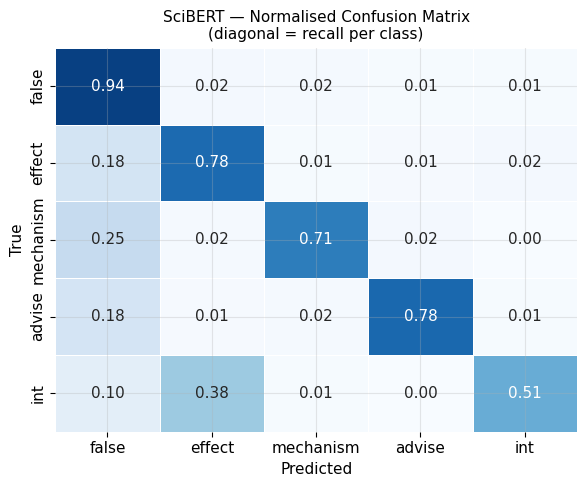

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))

cm  = confusion_matrix(y_true, y_pred)
idx = [CLASS_NAMES.index(l) for l in LABEL_ORDER]

cm_ord = cm[np.ix_(idx, idx)]

row_sums = cm_ord.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1

cm_norm = cm_ord / row_sums

sns.heatmap(
    cm_norm,
    ax=ax,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=LABEL_ORDER,
    yticklabels=LABEL_ORDER,
    vmin=0,
    vmax=1,
    cbar=False,
    linewidths=0.5
)

ax.set_title(
    f'{MODEL_NAME} — Normalised Confusion Matrix\n(diagonal = recall per class)',
    fontsize=11
)

ax.set_xlabel('Predicted')
ax.set_ylabel('True')

plt.tight_layout()
plt.savefig(FIG_DIR / 'scibert_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Per-Class F1 Score Analysis

This section presents the F1 score for each interaction class for the SciBERT model, providing a balanced view of precision and recall.

The dashed line indicates the macro-average F1 score, serving as a reference for overall performance. This visualisation helps compare class-wise performance and identify weaker classes that may require further improvement.

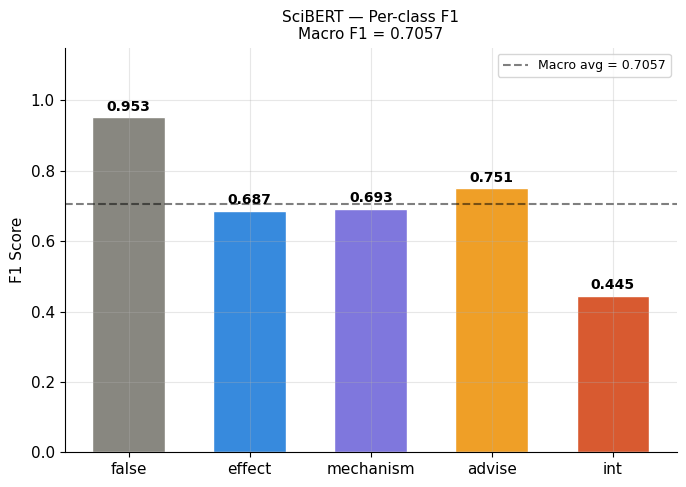

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))

rep = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

f1_per_class = [rep[lbl]['f1-score'] for lbl in LABEL_ORDER]
cols = [LABEL_COLOURS[l] for l in LABEL_ORDER]

bars = ax.bar(
    LABEL_ORDER,
    f1_per_class,
    color=cols,
    edgecolor='white',
    width=0.6
)

for bar, val in zip(bars, f1_per_class):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{val:.3f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

ax.set_title(
    f'{MODEL_NAME} — Per-class F1\nMacro F1 = {summary["macro_f1"]:.4f}',
    fontsize=11
)

ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.15)

ax.axhline(
    summary['macro_f1'],
    color='black',
    linestyle='--',
    alpha=0.5,
    label=f'Macro avg = {summary["macro_f1"]:.4f}'
)

ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'scibert_f1_scores.png', dpi=150, bbox_inches='tight')
plt.show()

## Saving Model and Results

The fine-tuned model, predictions, and evaluation results are saved for downstream analysis and comparison.

Outputs are structured to ensure consistency across all transformer models, enabling direct comparison in Phase 7.

In [10]:
model.save_pretrained(OUTPUT_DIR)
tokeniser.save_pretrained(OUTPUT_DIR)

pred_path = SCIBERT_PREDS_NPY
np.save(pred_path, y_pred)

gt_path = os.path.join(str(MODELS_DIR / 'shared'), 'y_test.npy')
np.save(gt_path, y_true)

res_path = SCIBERT_RESULTS_CSV
pd.DataFrame([summary]).to_csv(res_path, index=False)

with open(os.path.join(str(MODELS_DIR / 'shared'), 'label2id.json'), 'w') as f:
    json.dump(LABEL2ID, f)

print(f'{MODEL_NAME} final Macro F1 : {summary["macro_f1"]:.4f}')
print(f'MCC : {summary["mcc"]:.4f}')
print(f'Balanced Accuracy : {summary["bal_acc"]:.4f}')

SciBERT final Macro F1 : 0.7057
MCC : 0.6827
Balanced Accuracy : 0.7427


## Summary

Transformer-based models demonstrate strong capability in capturing complex biomedical relationships for DDI classification. The use of domain-specific pretrained models improves contextual understanding compared to classical approaches.

Class-weighted training effectively mitigates imbalance across interaction types, while Macro F1 provides a reliable primary evaluation metric. Visual and quantitative evaluations indicate that model performance varies across classes, highlighting challenges in distinguishing subtle interaction categories.

The outputs generated in this phase, including predictions and evaluation metrics, form the basis for systematic comparison across models in the next stage.